In [3]:
# Gerekli kütüphaneler
import os
import numpy as np
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt


In [2]:
real_dir = 'C:\\Users\\DELL\\Desktop\\real'
fake_dir = 'C:\\Users\\DELL\\Desktop\\fake'


In [4]:
# Gerçek ve sahte dosyaların listesini yazdırma
print("Gerçek resimler:", os.listdir(real_dir))
print("Sahte resimler:", os.listdir(fake_dir))

Gerçek resimler: ['10_face_1.jpg', '10_face_10.jpg', '10_face_100.jpg', '10_face_11.jpg', '10_face_13.jpg', '10_face_14.jpg', '10_face_15.jpg', '10_face_16.jpg', '10_face_17.jpg', '10_face_18.jpg', '10_face_19.jpg', '10_face_20.jpg', '10_face_21.jpg', '10_face_22.jpg', '10_face_23.jpg', '10_face_24.jpg', '10_face_25.jpg', '10_face_26.jpg', '10_face_27.jpg', '10_face_28.jpg', '10_face_29.jpg', '10_face_30.jpg', '10_face_31.jpg', '10_face_32.jpg', '10_face_34.jpg', '10_face_35.jpg', '10_face_36.jpg', '10_face_37.jpg', '10_face_38.jpg', '10_face_39.jpg', '10_face_4.jpg', '10_face_40.jpg', '10_face_41.jpg', '10_face_42.jpg', '10_face_43.jpg', '10_face_44.jpg', '10_face_45.jpg', '10_face_46.jpg', '10_face_47.jpg', '10_face_48.jpg', '10_face_49.jpg', '10_face_5.jpg', '10_face_50.jpg', '10_face_51.jpg', '10_face_52.jpg', '10_face_53.jpg', '10_face_54.jpg', '10_face_55.jpg', '10_face_56.jpg', '10_face_57.jpg', '10_face_58.jpg', '10_face_59.jpg', '10_face_6.jpg', '10_face_60.jpg', '10_face_61.j

In [6]:
# Gerçek ve sahte dosyaların sayısını yazdırma
print("Gerçek resim sayısı:", len(os.listdir(real_dir)))
print("Sahte resim sayısı:", len(os.listdir(fake_dir)))


Gerçek resim sayısı: 1937
Sahte resim sayısı: 1809


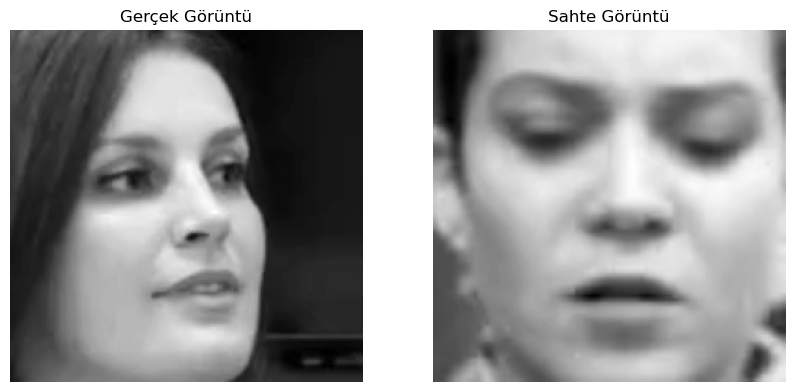

In [7]:
import cv2
import matplotlib.pyplot as plt
import os

# Gerçek resim okuma
real_image_path = os.path.join(real_dir, os.listdir(real_dir)[0])  # İlk dosyayı alıyoruz
real_image = cv2.imread(real_image_path, cv2.IMREAD_GRAYSCALE)  # Gri tonlama olarak okuma

# Sahte resim okuma
fake_image_path = os.path.join(fake_dir, os.listdir(fake_dir)[0])  # İlk dosyayı alıyoruz
fake_image = cv2.imread(fake_image_path, cv2.IMREAD_GRAYSCALE)  # Gri tonlama olarak okuma

# Gerçek resmi matplotlib ile gösterme
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(real_image, cmap='gray')  # Gri tonlamalı gösterim
plt.axis('off')
plt.title('Gerçek Görüntü')

# Sahte resmi matplotlib ile gösterme
plt.subplot(1, 2, 2)
plt.imshow(fake_image, cmap='gray')  # Gri tonlamalı gösterim
plt.axis('off')
plt.title('Sahte Görüntü')

plt.show()


In [11]:
import os
import numpy as np
import cv2
from sklearn.model_selection import train_test_split

In [13]:
# Verileri ve etiketleri saklamak için listeler
data = []
labels = []

# Resimleri yükleme fonksiyonu
def load_images_from_folder(folder, label):
    for file_name in os.listdir(folder):
        file_path = os.path.join(folder, file_name)
        image = cv2.imread(file_path)
        if image is not None:
            # Resmi uygun boyuta getiriyoruz
            image = cv2.resize(image, (128, 128))  # Model için standart boyut
            data.append(image)
            labels.append(label)

# Gerçek ve sahte resimleri yükleme
load_images_from_folder(real_dir, 1)  # Real için etiket 1
load_images_from_folder(fake_dir, 0)  # Fake için etiket 0

# Verileri ve etiketleri numpy dizilerine çevir
data = np.array(data, dtype="float32") / 255.0  # Normalizasyon
labels = np.array(labels)


In [14]:
from sklearn.model_selection import train_test_split

# Eğitim ve test setlerini ayır
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42, stratify=labels)

print("Eğitim seti boyutu:", X_train.shape)
print("Test seti boyutu:", X_test.shape)


Eğitim seti boyutu: (2790, 128, 128, 3)
Test seti boyutu: (698, 128, 128, 3)


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary sınıflandırma için sigmoid
])


C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_loss')

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, model_checkpoint]
)


Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 30s 323ms/step - accuracy: 0.5441 - loss: 0.7125 - val_accuracy: 0.6075 - val_loss: 0.6507
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 21s 295ms/step - accuracy: 0.6244 - loss: 0.6139 - val_accuracy: 0.6595 - val_loss: 0.5832
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 20s 291ms/step - accuracy: 0.6945 - loss: 0.5441 - val_accuracy: 0.7186 - val_loss: 0.5120
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 21s 291ms/step - accuracy: 0.7687 - loss: 0.4638 - val_accuracy: 0.7634 - val_loss: 0.4810
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 20s 287ms/step - accuracy: 0.8175 - loss: 0.3787 - val_accuracy: 0.8136 - val_loss: 0.4332
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 22s 316ms/step - accuracy: 0.8721 - loss: 0.2917 - val_accuracy: 0.7634 - val_loss: 0.4738
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 22s 316ms/step - accuracy: 0.8674 - loss: 0.2716 - val_accuracy: 0.8226 - val_loss: 0.4567
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 20s 290ms/step - accuracy: 0.9292 - loss: 0.1702 - val_accu

In [18]:
import cv2

def apply_gaussian_blur(image):
    # Gaussian Blur uygulama (Kernel boyutu 5x5)
    blurred_image = cv2.GaussianBlur(image, (5, 5), 0)
    return blurred_image


In [19]:
def equalize_histogram(image):
    equalized_image = cv2.equalizeHist(image)
    return equalized_image


In [20]:
def canny_edge_detection(image):
    edges = cv2.Canny(image, threshold1=100, threshold2=200)
    return edges


In [21]:
def adjust_contrast(image, alpha=1.5):
    adjusted_image = cv2.convertScaleAbs(image, alpha=alpha, beta=0)
    return adjusted_image


In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def augment_data(image):
    datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    # Veriyi artırarak döndürme
    augmented_image = datagen.random_transform(image)
    return augmented_image


In [23]:
from tensorflow.keras.layers import Dropout

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),
    Dropout(0.25),  # Overfitting'i önlemek için dropout
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary sınıflandırma için sigmoid
])


In [25]:
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [26]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True, monitor='val_loss')

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping, model_checkpoint]
)


Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 33s 362ms/step - accuracy: 0.5192 - loss: 0.7417 - val_accuracy: 0.5717 - val_loss: 0.6876
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 23s 326ms/step - accuracy: 0.5974 - loss: 0.6705 - val_accuracy: 0.5609 - val_loss: 0.6416
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 23s 331ms/step - accuracy: 0.5884 - loss: 0.6319 - val_accuracy: 0.6380 - val_loss: 0.6024
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 23s 329ms/step - accuracy: 0.6254 - loss: 0.6154 - val_accuracy: 0.6470 - val_loss: 0.5931
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 23s 333ms/step - accuracy: 0.6842 - loss: 0.5683 - val_accuracy: 0.6810 - val_loss: 0.5698
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 23s 332ms/step - accuracy: 0.7135 - loss: 0.5405 - val_accuracy: 0.7133 - val_loss: 0.5240
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 25s 362ms/step - accuracy: 0.7496 - loss: 0.4671 - val_accuracy: 0.7473 - val_loss: 0.4821
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 25s 362ms/step - accuracy: 0.7794 - loss: 0.4357 - val_accu

In [27]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Eğitim ve test setlerini ayır
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42, stratify=labels)

# Eğitim verisini doğrulama verisine ayır
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

print("Eğitim seti boyutu:", X_train.shape)
print("Doğrulama seti boyutu:", X_val.shape)
print("Test seti boyutu:", X_test.shape)

# Reduce learning rate when validation loss plateaus
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)


Eğitim seti boyutu: (2232, 128, 128, 3)
Doğrulama seti boyutu: (558, 128, 128, 3)
Test seti boyutu: (698, 128, 128, 3)


In [28]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

kf = KFold(n_splits=5, shuffle=True, random_state=42)
val_scores = []

for train_idx, val_idx in kf.split(X_train):
    X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import BatchNormalization

model = Sequential([
    Input(shape=(128, 128, 3)),  # Girdi şekli buraya tanımlanır
    BatchNormalization(), 
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.2),  # Overfitting'i önlemek için dropout
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.2),
    
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.2),
    
    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),  # L2 regularization ekledik
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # Binary sınıflandırma için sigmoid
])

# Modeli derle
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Modeli eğitirken early stopping'i ekle
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val), callbacks=[early_stopping])


Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 35s 382ms/step - accuracy: 0.5381 - loss: 2.3250 - val_accuracy: 0.5699 - val_loss: 0.9157
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 25s 361ms/step - accuracy: 0.6174 - loss: 0.8053 - val_accuracy: 0.6398 - val_loss: 0.7270
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 26s 372ms/step - accuracy: 0.6260 - loss: 0.6782 - val_accuracy: 0.6362 - val_loss: 0.6817
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 25s 361ms/step - accuracy: 0.6623 - loss: 0.6256 - val_accuracy: 0.5986 - val_loss: 0.7123
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 25s 362ms/step - accuracy: 0.6776 - loss: 0.6314 - val_accuracy: 0.6022 - val_loss: 0.6989
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 28s 393ms/step - accuracy: 0.6945 - loss: 0.6169 - val_accuracy: 0.7115 - val_loss: 0.6074
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 27s 388ms/step - accuracy: 0.7193 - loss: 0.5693 - val_accuracy: 0.6900 - val_loss: 0.5988
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 25s 362ms/step - accuracy: 0.7540 - loss: 0.5520 - val_accu

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import SGD

model = Sequential()

# Convolution + MaxPooling katmanları
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))  # 32 filtreli evrişim katmanı
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))  # 64 filtreli ikinci evrişim katmanı
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu'))  # 128 filtreli üçüncü evrişim katmanı
model.add(MaxPooling2D(pool_size=(2, 2)))

# Tam bağlantılı katmanlar
model.add(Flatten())  # Veriyi düzleştir
model.add(Dense(256, activation='relu'))  # 256 nöronlu tam bağlantılı katman
model.add(Dropout(0.2))  # Dropout ile aşırı öğrenmeyi engelle
model.add(Dense(1, activation='sigmoid'))  # Çift sınıflandırma için sigmoid aktivasyonu

# SGD optimizasyonunu ekleyerek modeli derleme
optimizer = SGD(learning_rate=0.001, momentum=0.9)  # SGD optimizasyonu
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Modelin eğitimi
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=20, batch_size=32, verbose=1)

# Performans değerlendirme
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Doğruluk: {test_accuracy:.2f}")


Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 12s 157ms/step - accuracy: 0.5004 - loss: 0.6925 - val_accuracy: 0.5186 - val_loss: 0.6891
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 161ms/step - accuracy: 0.5262 - loss: 0.6886 - val_accuracy: 0.5501 - val_loss: 0.6847
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 159ms/step - accuracy: 0.5699 - loss: 0.6813 - val_accuracy: 0.5688 - val_loss: 0.6784
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 156ms/step - accuracy: 0.6184 - loss: 0.6713 - val_accuracy: 0.5845 - val_loss: 0.6669
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 157ms/step - accuracy: 0.6102 - loss: 0.6634 - val_accuracy: 0.5587 - val_loss: 0.6629
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 155ms/step - accuracy: 0.5916 - loss: 0.6553 - val_accuracy: 0.5946 - val_loss: 0.6972
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 156ms/step - accuracy: 0.5820 - loss: 0.6622 - val_accuracy: 0.5989 - val_loss: 0.6760
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 11s 153ms/step - accuracy: 0.6061 - loss: 0.6362 - val_accu

In [33]:
# Gerekli kütüphanelerin yüklenmesi
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# ResNet50 modelini temel model olarak ekliyoruz (önceden eğitilmiş ImageNet ağırlıkları ile)
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Temel modeli eğitilmeyecek şekilde sabitliyoruz (transfer learning için)
resnet_base.trainable = False

# Model mimarisini oluşturma
model = Sequential([
    resnet_base,
    GlobalAveragePooling2D(),  # Özellikleri ortalama alarak küçültme
    Dense(256, activation='relu'),  # Ek katman
    Dropout(0.2),  # Overfitting'i engellemek için Dropout
    Dense(1, activation='sigmoid')  # Çift sınıf çıktısı için sigmoid aktivasyon fonksiyonu
])

# Modelin derlenmesi
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Erken durdurma ve model kaydetme callback'leri
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_resnet_model.keras', save_best_only=True)

# Modelin eğitilmesi
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)


Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 46s 548ms/step - accuracy: 0.5076 - loss: 0.7037 - val_accuracy: 0.5745 - val_loss: 0.6885
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 39s 565ms/step - accuracy: 0.5235 - loss: 0.6957 - val_accuracy: 0.5186 - val_loss: 0.7010
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 38s 543ms/step - accuracy: 0.5323 - loss: 0.6998 - val_accuracy: 0.5501 - val_loss: 0.6850
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 37s 531ms/step - accuracy: 0.5168 - loss: 0.6968 - val_accuracy: 0.5559 - val_loss: 0.6836
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 36s 521ms/step - accuracy: 0.5770 - loss: 0.6832 - val_accuracy: 0.5630 - val_loss: 0.6821
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 36s 510ms/step - accuracy: 0.5545 - loss: 0.6840 - val_accuracy: 0.5831 - val_loss: 0.6819
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 35s 496ms/step - accuracy: 0.5676 - loss: 0.6789 - val_accuracy: 0.5587 - val_loss: 0.6790
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 40s 577ms/step - accuracy: 0.5437 - loss: 0.6820 - val_accu

In [35]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# VGG16 modelini temel model olarak ekleme
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
vgg_base.trainable = False  # Ağırlıkları dondurma

# Model mimarisi
model = Sequential([
    vgg_base,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

# Model derleme
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Callback tanımları
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_vgg_model.keras', save_best_only=True)

# Model eğitimi
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=30, batch_size=32, callbacks=[early_stopping, model_checkpoint], verbose=1)


Epoch 1/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 70s 985ms/step - accuracy: 0.5466 - loss: 0.6961 - val_accuracy: 0.6719 - val_loss: 0.6113
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 68s 973ms/step - accuracy: 0.6799 - loss: 0.5962 - val_accuracy: 0.6032 - val_loss: 0.6649
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 67s 966ms/step - accuracy: 0.6830 - loss: 0.5933 - val_accuracy: 0.7149 - val_loss: 0.5529
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 67s 962ms/step - accuracy: 0.7348 - loss: 0.5168 - val_accuracy: 0.7364 - val_loss: 0.5314
Epoch 5/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 67s 962ms/step - accuracy: 0.7565 - loss: 0.5013 - val_accuracy: 0.7779 - val_loss: 0.5017
Epoch 6/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 67s 957ms/step - accuracy: 0.7834 - loss: 0.4678 - val_accuracy: 0.7178 - val_loss: 0.5335
Epoch 7/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 69s 984ms/step - accuracy: 0.7811 - loss: 0.4580 - val_accuracy: 0.7693 - val_loss: 0.4802
Epoch 8/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 68s 974ms/step - accuracy: 0.8052 - loss: 0.4227 - val_accu

In [37]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Xception modelini yükleme ve temel katmanları donma
xception_base = Xception(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
xception_base.trainable = False  # Transfer öğrenme için temel katmanları sabitle

# Model mimarisi
model_xception = Sequential([
    xception_base,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.2),  # Aşırı öğrenmeyi engellemek için Dropout
    Dense(1, activation='sigmoid')  # İkili sınıflandırma için sigmoid aktivasyonu
])

# Modelin derlenmesi
model_xception.compile(optimizer=Adam(learning_rate=0.001),
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_xception_model.keras', save_best_only=True)

# Model eğitimi
history_xception = model_xception.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)


Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 47s 600ms/step - accuracy: 0.6122 - loss: 0.6865 - val_accuracy: 0.7951 - val_loss: 0.4619
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 39s 560ms/step - accuracy: 0.8228 - loss: 0.4102 - val_accuracy: 0.7937 - val_loss: 0.4232
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 39s 561ms/step - accuracy: 0.8786 - loss: 0.3271 - val_accuracy: 0.8625 - val_loss: 0.3451
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 39s 558ms/step - accuracy: 0.9033 - loss: 0.2490 - val_accuracy: 0.8682 - val_loss: 0.3250
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 39s 558ms/step - accuracy: 0.9063 - loss: 0.2286 - val_accuracy: 0.8610 - val_loss: 0.3359
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 39s 557ms/step - accuracy: 0.9413 - loss: 0.1639 - val_accuracy: 0.8596 - val_loss: 0.3627
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 38s 549ms/step - accuracy: 0.9366 - loss: 0.1673 - val_accuracy: 0.8696 - val_loss: 0.3409
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 41s 580ms/step - accuracy: 0.9518 - loss: 0.1383 - val_accu

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


<Figure size 800x600 with 0 Axes>

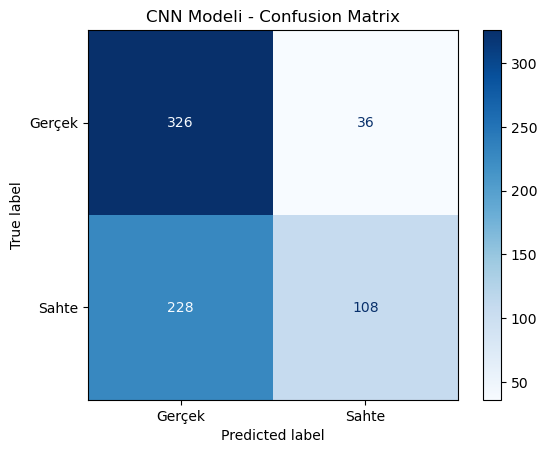

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Tahminleri al
y_pred = (model.predict(X_test) > 0.5).astype("int32")  # Tahminler 0.5 eşik değerine göre 0 veya 1 olarak sınıflandırılır.

# Confusion Matrix hesaplama
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Gerçek", "Sahte"])

# Confusion Matrix görselleştirme
plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title('CNN Modeli - Confusion Matrix')
plt.show()


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step


<Figure size 800x600 with 0 Axes>

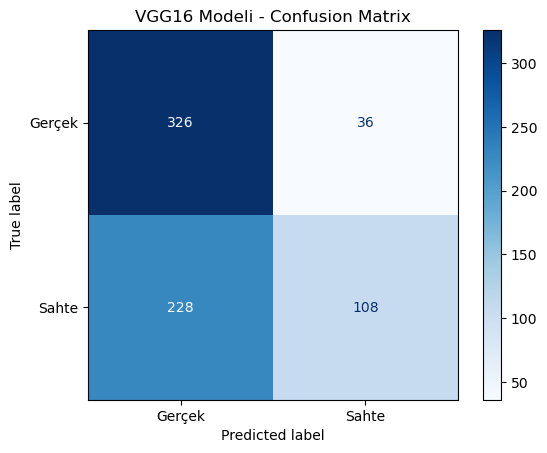

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# VGG16 modelinden tahminler al
y_pred_vgg = (model.predict(X_test) > 0.5).astype("int32")  # Tahminler 0 veya 1 olarak sınıflandırılır

# Confusion Matrix hesaplama
cm_vgg = confusion_matrix(y_test, y_pred_vgg)
disp_vgg = ConfusionMatrixDisplay(confusion_matrix=cm_vgg, display_labels=["Gerçek", "Sahte"])

# Confusion Matrix çizdirme
plt.figure(figsize=(8, 6))
disp_vgg.plot(cmap='Blues', values_format='d')
plt.title('VGG16 Modeli - Confusion Matrix')
plt.show()


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


<Figure size 800x600 with 0 Axes>

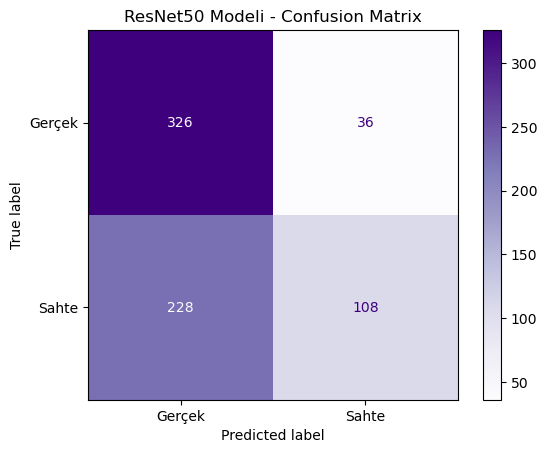

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ResNet50 modelinden tahminler al
y_pred_resnet = (model.predict(X_test) > 0.5).astype("int32")  # 0.5 eşik değerine göre sınıflandırma

# Confusion Matrix hesaplama
cm_resnet = confusion_matrix(y_test, y_pred_resnet)
disp_resnet = ConfusionMatrixDisplay(confusion_matrix=cm_resnet, display_labels=["Gerçek", "Sahte"])

# Confusion Matrix çizdirme
plt.figure(figsize=(8, 6))
disp_resnet.plot(cmap='Purples', values_format='d')
plt.title('ResNet50 Modeli - Confusion Matrix')
plt.show()


22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 402ms/step


<Figure size 800x600 with 0 Axes>

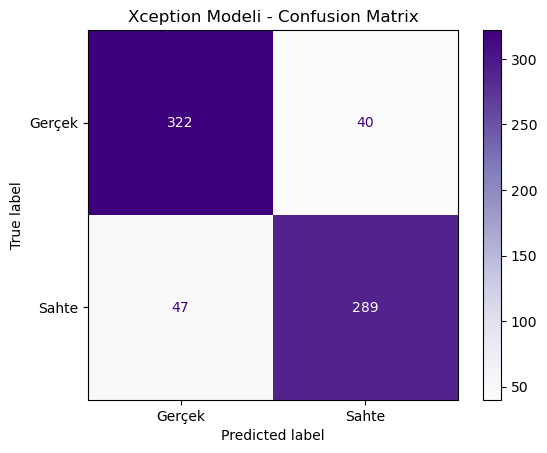

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Xception modelinden tahminler al
y_pred_xception = (model_xception.predict(X_test) > 0.5).astype("int32")  # 0.5 eşik değerine göre sınıflandırma

# Confusion Matrix hesaplama
cm_xception = confusion_matrix(y_test, y_pred_xception)
disp_xception = ConfusionMatrixDisplay(confusion_matrix=cm_xception, display_labels=["Gerçek", "Sahte"])

# Confusion Matrix çizdirme
plt.figure(figsize=(8, 6))
disp_xception.plot(cmap='Purples', values_format='d')
plt.title('Xception Modeli - Confusion Matrix')
plt.show()
